# Monte Carlo Simulation and the Mathematics of Gambling
## Can a player beat the casino in the long run?

Author: Yoan Angelov

## 1. Introduction

Gambling has existed for centuries and remains popular worldwide. Many players believe that with the right strategy, they can beat the casino. However, gambling games are designed using probability theory, which often guarantees a long-term advantage for the house.

This project investigates whether a player can mathematically beat the casino in the long run using Monte Carlo simulations.

I will simulate simple gambling games and analyze them using probability theory, expected value, and experimental results.

## 2. Problem Formulation


### Research Question

Is it mathematically possible for a player to beat the casino in the long run?

### Objectives

- Simulate simple gambling games using Python
- Compare theoretical probabilities with experimental results
- Analyze expected value
- Test a betting strategy ((Martingale system)  - After a loss, you double your next bet;Continue doing this until you succeed; When you win, you return to your initial bet.)
- Interpret results using mathematical reasoning

### Hypothesis

Although players may win in the short term, probability theory suggests that long-term profit is unlikely due to the house edge.

## 3. Theoretical Background
### 3.1 Basic Probability
Probability measures how likely an event is to occur. It ranges between 0 and 1.
For example, in a fair coin toss:
- P(Heads) = 0.5
- P(Tails) = 0.5
### 3.2 Expected Value
Expected value (EV) represents the average outcome of a game over many repetitions.

Formula:
E = (probability of win × win amount) + (probability of loss × loss amount)

If EV = 0 → fair game  
If EV < 0 → player loses long-term  
If EV > 0 → player wins long-term 

### 3.3 Law of Large Numbers
The Law of Large Numbers states that as the number of trials increases, experimental results approach theoretical probabilities.

This concept is fundamental in Monte Carlo simulations.


## 4. Game 1: Coin Flip Simulation

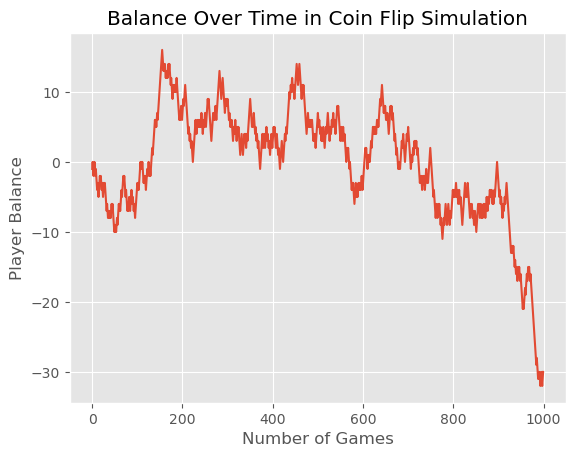

In [26]:
import random
import matplotlib.pyplot as plt

def simulate_coin_flips(num_flips):

    balance = 0
    balances = []

    for i in range(num_flips):

        flip = random.choice(["H", "T"])

        if flip == "H":
            balance += 1
        else:
            balance -= 1

        balances.append(balance)

    return balances


results = simulate_coin_flips(1000)

plt.plot(results)
plt.title("Balance Over Time in Coin Flip Simulation")
plt.xlabel("Number of Games")
plt.ylabel("Player Balance")

plt.show()


The graph shows how the player's balance changes over time.
Even though the expected value of the game is zero, short-term
results fluctuate randomly due to variance.

Note: The simulation starts with a balance of 0. 
This represents the player's net profit or loss relative to the starting point.

## 5. Game 2: Roulette Simulation
### 5.1 Theoretical Analysis

Roulette is a classic casino game with well-known probabilities.

In European roulette there are 37 numbers:
0, 1, 2, ..., 36

If a player bets on a single number:

Probability of winning = 1 / 37  
Probability of losing = 36 / 37

The payout for a correct number bet is 35:1.

The expected value can be calculated as:

EV = (1/37 × 35) + (36/37 × -1)

EV ≈ -0.027

This means that the player loses about **2.7% per bet on average**, which represents the **house edge**.


### 5.2 Implementation

In [28]:
import random

def roulette_simulation(num_spins):

    balance = 0
    results = []

    for _ in range(num_spins):

        spin = random.randint(0, 36)

        if spin == 7:  # player bets on number 7
            balance += 35
        else:
            balance -= 1

        results.append(balance)

    return results

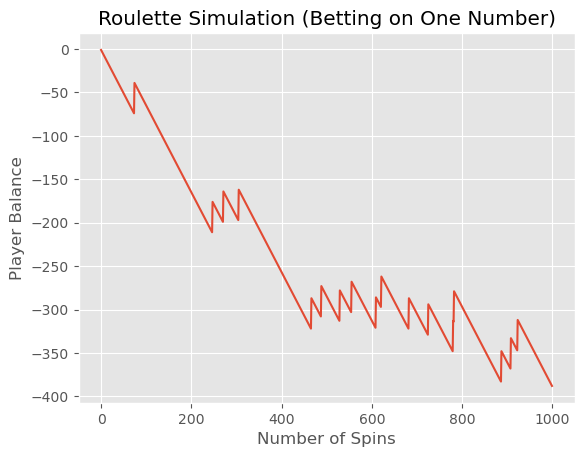

In [19]:
import matplotlib.pyplot as plt

results = roulette_simulation(1000)

plt.plot(results)

plt.title("Roulette Simulation (Betting on One Number)")
plt.xlabel("Number of Spins")
plt.ylabel("Player Balance")

plt.show()

This will show how the balance almost always falls down.

## 6. Betting Strategy: Martingale System
The Martingale strategy doubles the bet after each loss.

The idea is that one win recovers all previous losses.

We will test whether this strategy overcomes the house edge.


In [3]:
import random
import matplotlib.pyplot as plt

def martingale_simulation(spins, base_bet=1):

    balance = 0
    bet = base_bet
    balances = []

    for i in range(spins):

        spin = random.randint(0, 36)

        if spin == 7:   # chosen number
            balance += 35 * bet
            bet = base_bet
        else:
            balance -= bet
            bet *= 2

        balances.append(balance)

    return balances

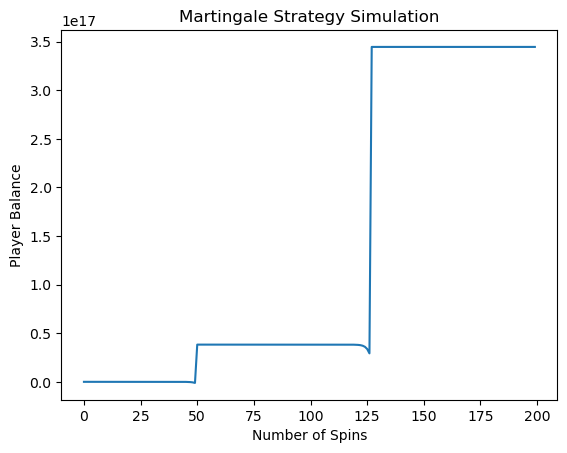

In [4]:
result = martingale_simulation(200)

plt.plot(result)

plt.title("Martingale Strategy Simulation")
plt.xlabel("Number of Spins")
plt.ylabel("Player Balance")

plt.show()


## 7. Experimental Results
### 7.1 Coin Flip Results
The coin flip simulation shows fluctuations around zero. This is expected
because the game is fair and has an expected value of zero.

### 7.2 Roulette Results
The roulette simulation demonstrates a downward trend over time. This occurs
because the house edge gives the casino a statistical advantage.

### 7.3 Martingale Results
The Martingale strategy appears successful in the short term because small
losses are recovered quickly. However, when a long losing streak occurs, the
required bet grows exponentially, leading to very large losses.

## 8. Discussion

- Why short-term wins are misleading - Short sequences of wins can create the illusion that a strategy works.
However, probability ensures that losing streaks will eventually occur.
- The role of variance - Variance causes large fluctuations in short-term results. Monte Carlo
simulations help visualize how randomness behaves over time.
- The importance of expected value - Expected value determines the long-term outcome of a game. If the expected
value is negative, no betting strategy can overcome the house edge in the
long run 


## 9. Conclusion

This project demonstrated that although gambling may produce short-term gains,
probability theory and simulations confirm that long-term profit is unlikely in games with negative expected value.

## References
Grinstead and Snell’s Introduction to Probability - https://math.dartmouth.edu/~prob/prob/prob.pdf
Wikipedia – Expected Value
Wikipedia – Martingale Betting System